# Heart Disease Prediction — Exploratory Data Analysis

## Overview

This project explores the Cleveland Heart Disease dataset and prepares the data for a binary classification task.

The original target variable contains multiple classes representing different levels of heart disease. For this project, the target is converted into a binary variable:

- `0` → No heart disease
- `1` → Presence of heart disease

The main objectives of this notebook are:

1. Understand the structure of the dataset
2. Identify and handle missing values
3. Analyze feature distributions
4. Explore relationships between features and the target
5. Prepare the dataset for machine learning
6. Create a clean train/test split without data leakage

In [634]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

##  Load the Dataset

In [635]:
data = pd.read_csv(
    "../data/processed.cleveland.data",
    header=None,
    na_values="?"
)

In [636]:
print(data.shape)

(303, 14)


In [637]:
data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [638]:
data.columns = ["age", "sex", "cp", "trestbps","chol","fbs","restecg","thalach",
                "exang","oldpeak","slope","ca","thal","num",]
print(data.head(2))

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   

   slope   ca  thal  num  
0    3.0  0.0   6.0    0  
1    2.0  3.0   3.0    2  


In [639]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [640]:
data.dtypes

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
num           int64
dtype: object

In [641]:
missing_values = data.isna().sum()

missing_values[missing_values > 0]

ca      4
thal    2
dtype: int64

In [642]:
missing_percentage = (
    data.isna().mean() * 100
).sort_values(ascending=False)

missing_percentage[missing_percentage > 0]

ca      1.320132
thal    0.660066
dtype: float64

In [643]:
data["num"].value_counts().sort_index()

num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

In [644]:
data["num"].value_counts(normalize=True).sort_index()

num
0    0.541254
1    0.181518
2    0.118812
3    0.115512
4    0.042904
Name: proportion, dtype: float64

In [645]:
data.rename(columns={'num': 'original target'}, inplace=True)

In [646]:
data.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'original target'],
      dtype='str')

In [647]:
data["binary target"] = (data["original target"] > 0).astype(int)

### Target Transformation

The original target variable contains five classes (0–4).

For this project, the problem is converted into binary classification:

- `0` → No heart disease
- `1` → Presence of heart disease

Therefore, all original target values greater than 0 are mapped to 1.

In [648]:
data[["original target", "binary target"]].head(5)

,original target,binary target
0,0,0
1,2,1
2,1,1
3,0,0
4,0,0


In [649]:
data["binary target"].value_counts().sort_index()

binary target
0    164
1    139
Name: count, dtype: int64

In [650]:
data["binary target"].value_counts(normalize=True).sort_index()

binary target
0    0.541254
1    0.458746
Name: proportion, dtype: float64

In [651]:
data.isna().sum()

age                0
sex                0
cp                 0
trestbps           0
chol               0
fbs                0
restecg            0
thalach            0
exang              0
oldpeak            0
slope              0
ca                 4
thal               2
original target    0
binary target      0
dtype: int64

In [652]:
data.dtypes

age                float64
sex                float64
cp                 float64
trestbps           float64
chol               float64
fbs                float64
restecg            float64
thalach            float64
exang              float64
oldpeak            float64
slope              float64
ca                 float64
thal               float64
original target      int64
binary target        int64
dtype: object

In [653]:
data["ca"] = pd.to_numeric(data["ca"])
data["thal"] = pd.to_numeric(data["thal"])

In [654]:
data.isna().sum()

age                0
sex                0
cp                 0
trestbps           0
chol               0
fbs                0
restecg            0
thalach            0
exang              0
oldpeak            0
slope              0
ca                 4
thal               2
original target    0
binary target      0
dtype: int64

In [655]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,original target,binary target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000,1.000000


In [656]:
data.nunique()

age                 41
sex                  2
cp                   4
trestbps            50
chol               152
fbs                  2
restecg              3
thalach             91
exang                2
oldpeak             40
slope                3
ca                   4
thal                 3
original target      5
binary target        2
dtype: int64

In [657]:
data["binary target"].value_counts()

binary target
0    164
1    139
Name: count, dtype: int64

In [658]:
data["binary target"].value_counts(normalize=True)

binary target
0    0.541254
1    0.458746
Name: proportion, dtype: float64

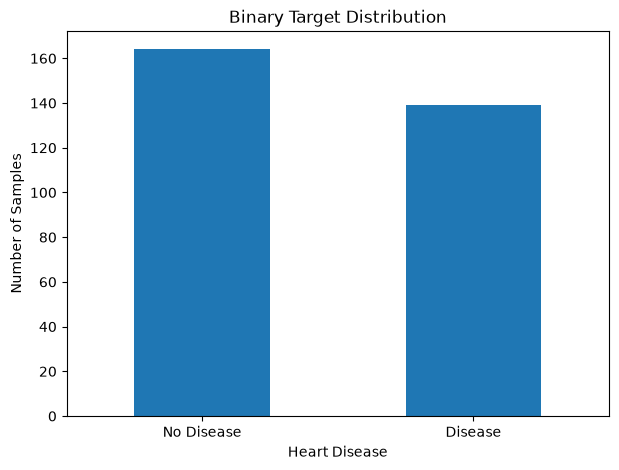

In [659]:
plt.figure(figsize=(7, 5))

data["binary target"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Binary Target Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Samples")
plt.xticks(
    [0, 1],
    ["No Disease", "Disease"],
    rotation=0
)

plt.show()

## Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the structure, distribution, and characteristics of the dataset before building the neural network.

In this stage, we examine:

- Summary statistics
- Unique values of the features
- Missing values
- Target distribution
- Feature distributions and relationships

## Feature Types

Although all features are stored as numerical values, they do not all represent continuous numerical variables.

### Continuous Features

- `age`
- `trestbps`
- `chol`
- `thalach`
- `oldpeak`

These features represent measurable quantities and can take values across a numerical range.

### Binary Features

- `sex`
- `fbs`
- `exang`

These features have two possible categories, represented by 0 and 1.

### Categorical Features

- `cp`
- `restecg`
- `slope`
- `ca`
- `thal`

These features use numerical codes to represent different categories. Therefore, their numerical values should not automatically be interpreted as continuous quantities.

### Target Variables

- `original target`: original five-class target (0–4)
- `binary target`: binary target (0 = no heart disease, 1 = heart disease)

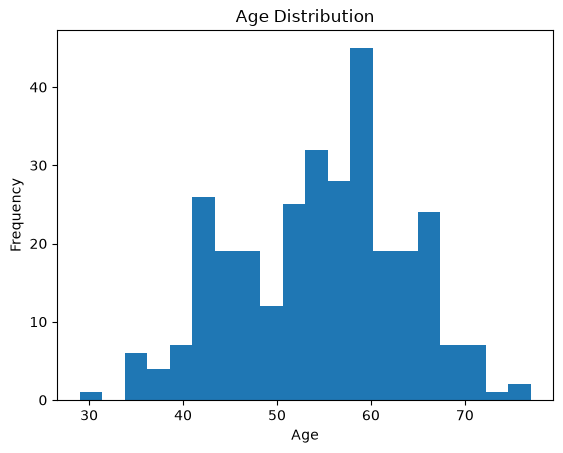

In [660]:
data["age"].plot(kind="hist", bins=20)
plt.xlabel("Age")
plt.title("Age Distribution")
plt.show()

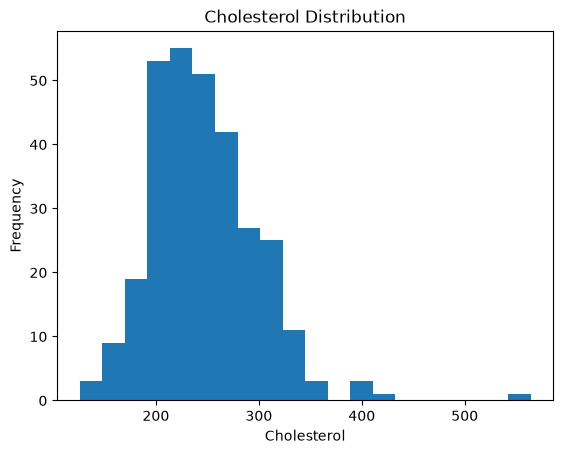

In [661]:
data["chol"].plot(kind="hist", bins=20)
plt.xlabel("Cholesterol")
plt.title("Cholesterol Distribution")
plt.show()

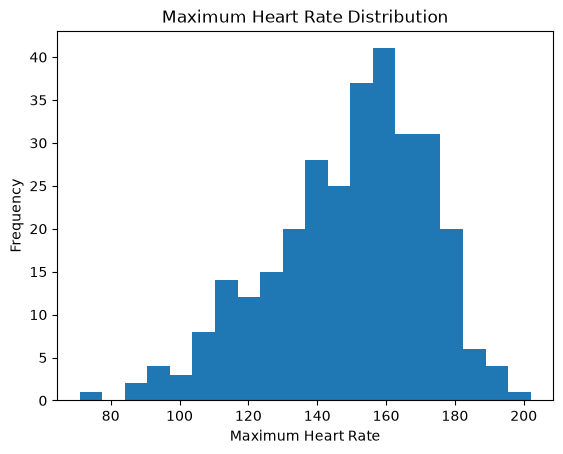

In [662]:
data["thalach"].plot(kind="hist", bins=20)
plt.xlabel("Maximum Heart Rate")
plt.title("Maximum Heart Rate Distribution")
plt.show()

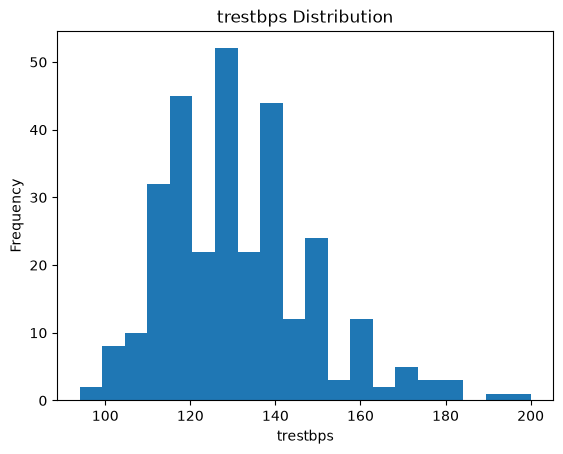

In [663]:
data["trestbps"].plot(kind="hist", bins=20)
plt.xlabel("trestbps")
plt.title("trestbps Distribution")
plt.show()

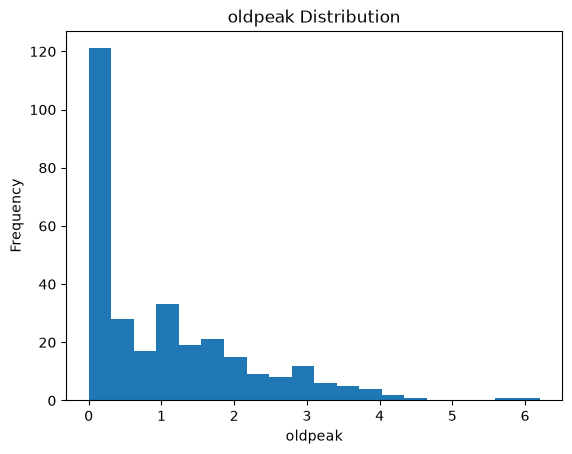

In [664]:
data["oldpeak"].plot(kind="hist", bins=20)
plt.xlabel("oldpeak")
plt.title("oldpeak Distribution")
plt.show()

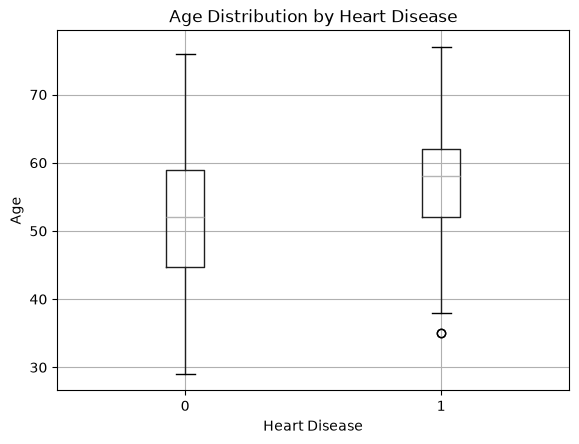

In [665]:
data.boxplot(column="age", by="binary target")
plt.title("Age Distribution by Heart Disease")
plt.suptitle("")
plt.xlabel("Heart Disease")
plt.ylabel("Age")
plt.show()

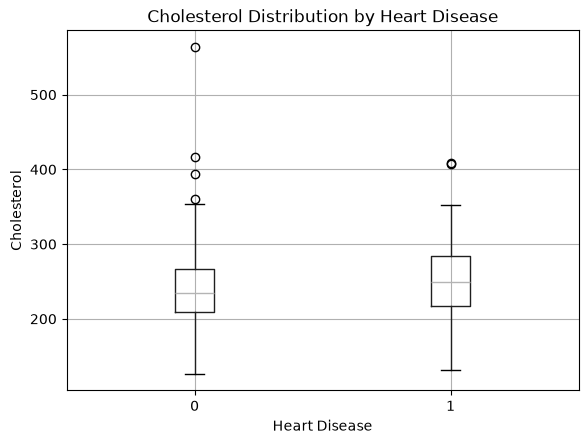

In [666]:
data.boxplot(column="chol", by="binary target")
plt.title("Cholesterol Distribution by Heart Disease")
plt.suptitle("")
plt.xlabel("Heart Disease")
plt.ylabel("Cholesterol")
plt.show()

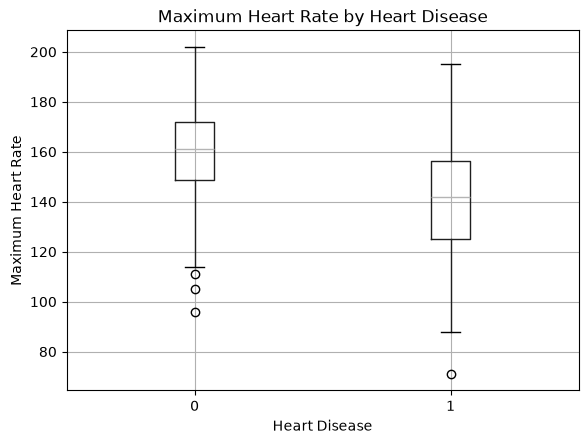

In [667]:
data.boxplot(column="thalach", by="binary target")
plt.title("Maximum Heart Rate by Heart Disease")
plt.suptitle("")
plt.xlabel("Heart Disease")
plt.ylabel("Maximum Heart Rate")
plt.show()

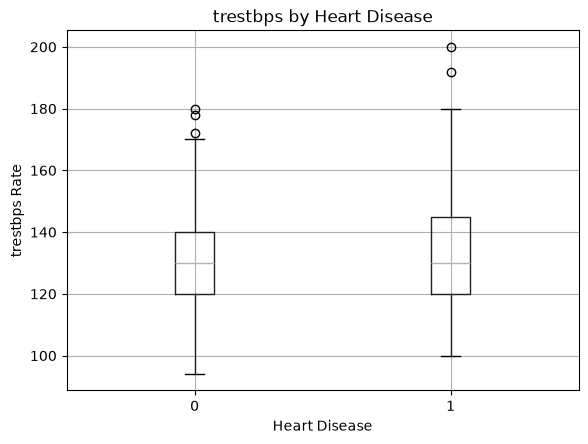

In [668]:
data.boxplot(column="trestbps", by="binary target")
plt.title("trestbps by Heart Disease")
plt.suptitle("")
plt.xlabel("Heart Disease")
plt.ylabel("trestbps Rate")
plt.show()

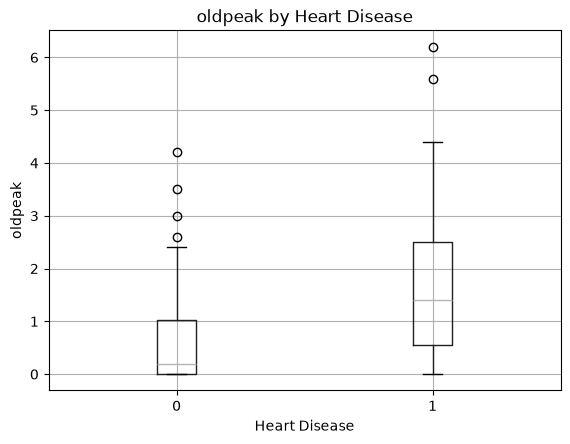

In [669]:
data.boxplot(column="oldpeak", by="binary target")
plt.title("oldpeak by Heart Disease")
plt.suptitle("")
plt.xlabel("Heart Disease")
plt.ylabel("oldpeak")
plt.show()

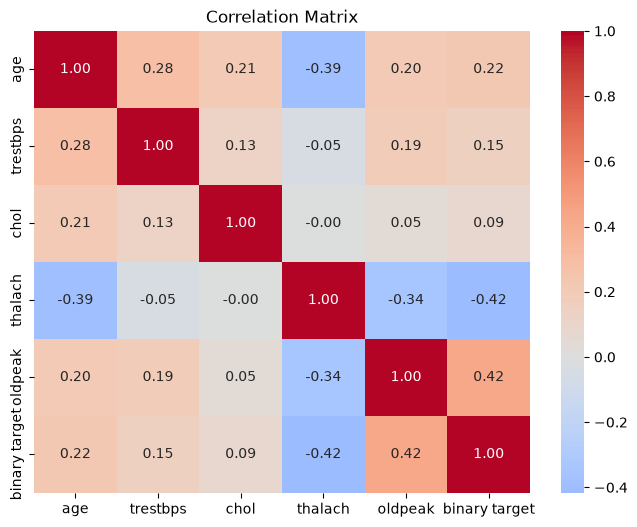

In [670]:
correlation_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "binary target"
]

corr = data[correlation_features].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [671]:
pd.crosstab(data["cp"], data["binary target"])

binary target,0,1
cp,,
1.0,16,7
2.0,41,9
3.0,68,18
4.0,39,105


In [672]:
pd.crosstab(data["restecg"], data["binary target"])

binary target,0,1
restecg,,
0.0,95,56
1.0,1,3
2.0,68,80


In [673]:
pd.crosstab(data["slope"], data["binary target"])

binary target,0,1
slope,,
1.0,106,36
2.0,49,91
3.0,9,12


In [674]:
pd.crosstab(data["ca"], data["binary target"])

binary target,0,1
ca,,
0.0,130,46
1.0,21,44
2.0,7,31
3.0,3,17


In [675]:
pd.crosstab(data["thal"], data["binary target"])

binary target,0,1
thal,,
3.0,129,37
6.0,6,12
7.0,28,89


### Missing-Value Handling

The dataset contains six missing values: four in `ca` and two in `thal`.

Instead of removing observations, missing values will be handled after the train/test split to avoid unnecessary data loss and prevent information leakage.

The imputation values will be calculated using the training set only and then applied to both training and test sets.

In [676]:
print(data.shape)
print(data.isna().sum())
print(data.dtypes)

(303, 15)
age                0
sex                0
cp                 0
trestbps           0
chol               0
fbs                0
restecg            0
thalach            0
exang              0
oldpeak            0
slope              0
ca                 4
thal               2
original target    0
binary target      0
dtype: int64
age                float64
sex                float64
cp                 float64
trestbps           float64
chol               float64
fbs                float64
restecg            float64
thalach            float64
exang              float64
oldpeak            float64
slope              float64
ca                 float64
thal               float64
original target      int64
binary target        int64
dtype: object


In [677]:
X = data.drop(columns=["original target", "binary target"])
y = data["binary target"]
print(X.shape)
print(y.shape)

(303, 13)
(303,)


In [678]:
print(y.value_counts())
print(y.value_counts(normalize=True)*100)

binary target
0    164
1    139
Name: count, dtype: int64
binary target
0    54.125413
1    45.874587
Name: proportion, dtype: float64


In [679]:
print(X.head())

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  
0    3.0  0.0   6.0  
1    2.0  3.0   3.0  
2    2.0  2.0   7.0  
3    3.0  0.0   3.0  
4    1.0  0.0   3.0  


In [680]:
numerical_features = [
    "age", "trestbps", "chol", "thalach", "oldpeak"
]

binary_features = [
    "sex", "fbs", "exang"
]

categorical_features = [
    "cp", "restecg", "slope", "thal"
]

ordinal_features = [
    "ca"
]

print("Numerical:", numerical_features)
print("Binary:", binary_features)
print("Categorical:", categorical_features)
print("Ordinal:", ordinal_features)

Numerical: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Binary: ['sex', 'fbs', 'exang']
Categorical: ['cp', 'restecg', 'slope', 'thal']
Ordinal: ['ca']


In [681]:
print(X.shape)
print(X.head())

(303, 13)
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  
0    3.0  0.0   6.0  
1    2.0  3.0   3.0  
2    2.0  2.0   7.0  
3    3.0  0.0   3.0  
4    1.0  0.0   3.0  


In [682]:
print(X.columns.tolist())
print(X.dtypes)
print(X.shape)
print(X.isna().sum().sum())

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
dtype: object
(303, 13)
6


In [683]:
print(y.unique())
print(y.shape)

[0 1]
(303,)


In [684]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("\nX_test:", X_test.shape)
print("\ny_train:", y_train.shape)
print("\ny_test:", y_test.shape)

print("\nTrain:")
print(y_train.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))

X_train: (242, 13)

X_test: (61, 13)

y_train: (242,)

y_test: (61,)

Train:
binary target
0    0.541322
1    0.458678
Name: proportion, dtype: float64

Test:
binary target
0    0.540984
1    0.459016
Name: proportion, dtype: float64


In [685]:
for column in ["ca", "thal"]:
    median_value = X_train[column].median()

    X_train[column] = X_train[column].fillna(median_value)
    X_test[column] = X_test[column].fillna(median_value)

In [686]:
X_train = pd.get_dummies(
    X_train,
    columns=categorical_features,
    dtype=float
)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_features,
    dtype=float
)

In [687]:
X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

In [688]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [689]:
print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)


X_train shape: (242, 22)
X_test shape: (61, 22)


In [690]:
print("Mean of scaled training features:")
print(X_train_scaled.mean(axis=0))

print("\nStd of scaled training features:")
print(X_train_scaled.std(axis=0))

Mean of scaled training features:
[-1.83507938e-16  1.02764445e-16 -3.85366670e-16  1.46806350e-16
 -2.20209526e-17 -7.34031752e-18  1.37630953e-18  0.00000000e+00
  7.34031752e-17  1.46806350e-17  4.40419051e-17 -3.67015876e-18
 -5.13822226e-17  1.65157144e-17  1.46806350e-17  4.26655956e-17
  0.00000000e+00 -9.35890484e-17 -2.56911113e-17  4.22068257e-17
 -6.60628577e-17 -7.34031752e-18]

Std of scaled training features:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [691]:
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

## Data Preprocessing

The preprocessing pipeline consists of:

1. Separating features and target
2. Splitting the data into training and test sets
3. Handling missing values using statistics calculated from the training set
4. One-hot encoding categorical features
5. Applying the same feature structure to the test set
6. Standardizing numerical inputs using a scaler fitted only on the training set

In [692]:
print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (242, 22)
X_test shape: (61, 22)
y_train shape: (242,)
y_test shape: (61,)


In [693]:
np.save("../data/X_train_scaled.npy", X_train_scaled)
np.save("../data/X_test_scaled.npy", X_test_scaled)

np.save("../data/y_train.npy", y_train)
np.save("../data/y_test.npy", y_test)

In [694]:
feature_names = X_train.columns.tolist()

np.save(
    "../data/feature_names.npy",
    np.array(feature_names)
)